# Visual Diagnostics
Suppose a data scientist has decided to use linear regression to estimate values of one variable (called the **response** variable) based on another variable (called the **predictor**). To see how well this method of estimation performs, the data scientist must measure how far off the estimates are from the actual values. These differences are called ***residuals*** ("errors").

$$
\mbox{residual} ~=~ \mbox{observed value} ~-~ \mbox{regression estimate}
$$

A residual is what's left over – the residue – after estimation. 

Residuals are the vertical distances of the points from the regression line. There is one residual for each point in the scatter plot. The residual is the difference between the observed value of $y$ and the fitted value of $y$, so for the point $(x, y)$,

$$
\mbox{residual} ~~ = ~~ y ~-~
\mbox{fitted value of }y
~~ = ~~ y ~-~
\mbox{height of regression line at }x
$$

The function `residual` calculates the residuals. The calculation assumes all the relevant functions we have already defined: `standard_units`, `correlation`, `slope`, `intercept`, and `fit`.

In [1]:
path_data = '../../data/'

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

```{contents}
:local:
:depth: 2
```


In [2]:
family_heights = pd.read_csv(path_data + 'family_heights.csv')
heights = family_heights[['midparentHeight', 'childHeight']]
heights = heights.rename(columns={'midparentHeight':'MidParent', 'childHeight':'Child'})

hybrid = pd.read_csv(path_data + 'hybrid.csv')

In [3]:
def standard_units(x):
    return (x - np.mean(x))/np.std(x)

def standard_units(any_numbers):
    "Convert any array of numbers to standard units."
    return (any_numbers - np.mean(any_numbers))/np.std(any_numbers)  

def correlation(t, x, y):
    return np.mean(standard_units(t[x])*standard_units(t[y]))

def slope(table, x, y):
    r = correlation(table, x, y)
    return r * np.std(table[y])/np.std(table[x])

def intercept(table, x, y):
    a = slope(table, x, y)
    return np.mean(table[y]) - a * np.mean(table[x])

def fit(table, x, y):
    """Return the height of the regression line at each x value."""
    a = slope(table, x, y)
    b = intercept(table, x, y)
    return a * table[x] + b

In [4]:
def residual(table, x, y):
    return table[y] - fit(table, x, y)

Continuing our example of estimating the heights of adult children (the response) based on the midparent height (the predictor), let us calculate the fitted values and the residuals.

In [5]:
heights['Fitted Vlaue'] = fit(heights, 'MidParent', 'Child')
heights['Residual'] = residual(heights, 'MidParent', 'Child')
heights

,MidParent,Child,Fitted Vlaue,Residual
0,75.43,73.2,70.712373,2.487627
1,75.43,69.2,70.712373,-1.512373
2,75.43,69.0,70.712373,-1.712373
3,75.43,69.0,70.712373,-1.712373
4,73.66,73.5,69.584244,3.915756
...,...,...,...,...
929,66.64,64.0,65.109971,-1.109971
930,66.64,62.0,65.109971,-3.109971
931,66.64,61.0,65.109971,-4.109971
932,65.27,66.5,64.236786,2.263214


When there are so many variables to work with, it is always helpful to start with visualization. The function `scatter_fit` draws the scatter plot of the data, as well as the regression line. 

In [6]:
def scatter_fit(table, x, y):
    plt.figure(figsize=(4,4))
    table.plot.scatter(x, y, s=10, figsize=(4,4))
    plt.plot(table[x], fit(table, x, y), lw=3, color='gold')
    plt.xlabel(x)
    plt.ylabel(y)


<Figure size 400x400 with 0 Axes>

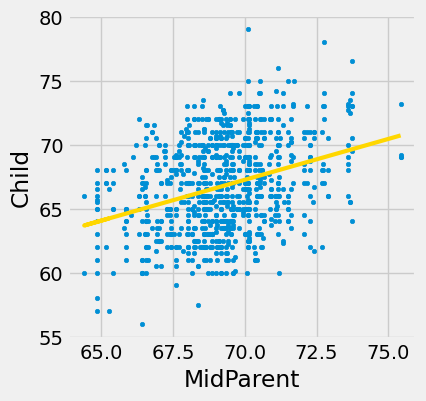

In [7]:
scatter_fit(heights, 'MidParent', 'Child')

A *residual plot* can be drawn by plotting the residuals against the predictor variable. The function `residual_plot` does just that. 

In [8]:
def residual_plot(table, x, y):
    
    x_array = table[x]
    t = pd.DataFrame({x:x_array, 
                      'residuals':residual(table, x, y)})

    fig, ax = plt.subplots(figsize=(4, 4))
    
    ax.scatter(t[x], t['residuals'], color='r', s=10)
    xlims = np.array([min(x_array), max(x_array)])
    ax.plot(xlims, np.array([0, 0]), color='darkblue', lw=2)

    x_label = x
    y_label = y
    y_vals = ax.get_yticks()
    plt.ylabel(y_label)
    plt.xlabel(x_label)  
    plt.title('Residual Plot')
    plt.show()

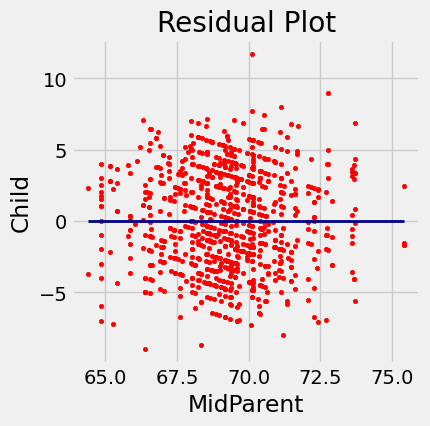

In [9]:
residual_plot(heights, 'MidParent', 'Child')

The midparent heights are on the horizontal axis, as in the original scatter plot. But now the vertical axis shows the residuals. Notice that the plot appears to be centered around the horizontal line at the level 0 (shown in dark blue). Notice also that the plot shows no upward or downward trend. We will observe later that this lack of trend is true of all regressions.

## Regression Diagnostics
Residual plots help us make visual **assessments of the quality of a linear regression** analysis. Such assessments are called *diagnostics*. The function ``regression_diagnostic_plots`` draws the original scatter plot as well as the residual plot for ease of comparison.

In [10]:
def regression_diagnostic_plots(table, x, y):
    plt.figure(figsize=(4,4))
    scatter_fit(table, x, y)
    residual_plot(table, x, y)

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

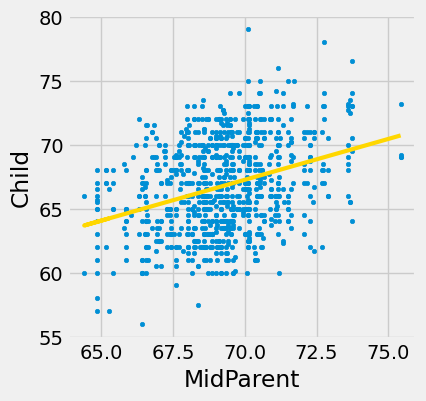

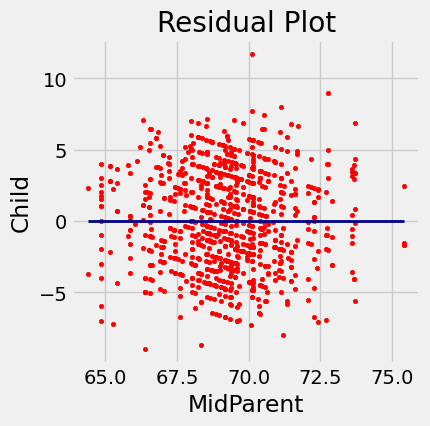

In [11]:
regression_diagnostic_plots(heights, 'MidParent', 'Child')

This residual plot indicates that linear regression was a reasonable method of estimation. Notice how the residuals are distributed fairly symmetrically above and below the horizontal line at 0, corresponding to the original scatter plot being roughly symmetrical above and below. Notice also that the vertical spread of the plot is fairly even across the most common values of the children's heights. In other words, apart from a few outlying points, the plot isn't narrower in some places and wider in others.

In other words, the accuracy of the regression appears to be about the same across the observed range of the predictor variable. 

**The residual plot of a good regression shows no pattern. The residuals look about the same, above and below the horizontal line at 0, across the range of the predictor variable.**

## Detecting Nonlinearity
Drawing the scatter plot of the data usually gives an indication of whether the relation between the two variables is non-linear. Often, however, it is easier to spot non-linearity in a residual plot than in the original scatter plot. This is usually because of the scales of the two plots: the residual plot allows us to zoom in on the errors and hence makes it easier to spot patterns.

<img src="https://upload.wikimedia.org/wikipedia/commons/7/75/Dugong_dugon.jpg"/>

Our data are a [dataset](http://www.statsci.org/data/oz/dugongs.html)  on the age and length of dugongs, which are marine mammals related to manatees and sea cows (image from [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Dugong_dugon.jpg)). The data are in a table called `dugong`. Age is measured in years and length in meters. Because dugongs tend not to keep track of their birthdays, ages are estimated based on variables such as the condition of their teeth.

In [12]:
def move_to_front(df, col_name):
    return df[[col_name] + [c for c in df.columns if c != col_name]]

dugong = pd.read_csv(path_data + 'dugongs.csv')
dugong = move_to_front(dugong, 'Length')
dugong.head()

,Length,Age
0,1.80,1.0
1,1.85,1.5
2,1.87,1.5
3,1.77,1.5
4,2.02,2.5


If we could measure the length of a dugong, what could we say about its age? Let's examine what our data say. Here is a regression of age (the response) on length (the predictor). The correlation between the two variables is substantial, at 0.83.

In [13]:
correlation(dugong, 'Length', 'Age').item()

0.8296474554905714

High correlation notwithstanding, the plot shows a curved pattern that is much more visible in the residual plot.

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

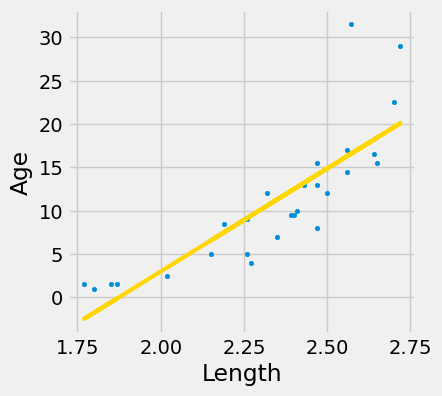

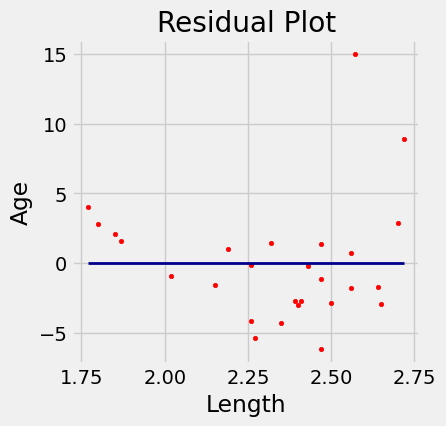

In [14]:
regression_diagnostic_plots(dugong, 'Length', 'Age')

While you can spot the non-linearity in the original scatter, it is more clearly evident in the residual plot.

At the low end of the lengths, the residuals are almost all positive; then they are almost all negative; then positive again at the high end of lengths. In other words the regression estimates have a pattern of being too high, then too low, then too high. That means it would have been better to use a curve instead of a straight line to estimate the ages.

**When a residual plot shows a pattern, there may be a non-linear relation between the variables.**

## Detecting Heteroscedasticity

*Heteroscedasticity* is a word that will surely be of interest to those who are preparing for Spelling Bees. For data scientists, its interest lies in its meaning, which is "uneven spread". 

Recall the table `hybrid` that contains data on hybrid cars in the U.S. Here is a regression of fuel efficiency on the rate of acceleration. The association is negative: cars that accelearate quickly tend to be less efficient.

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

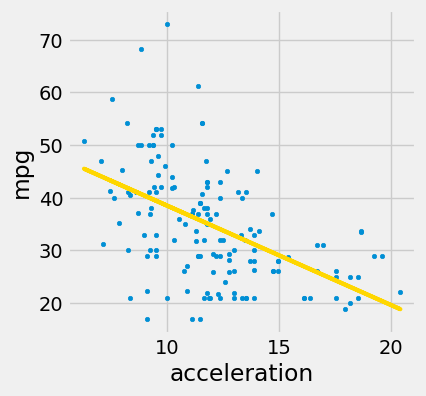

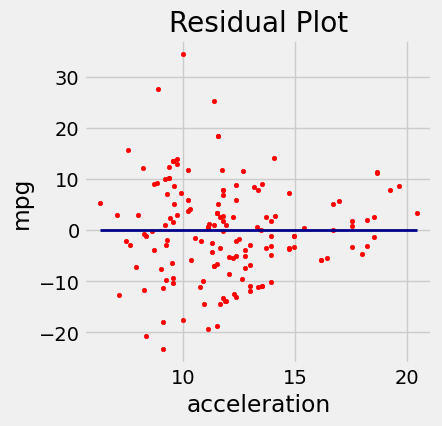

In [15]:
regression_diagnostic_plots(hybrid, 'acceleration', 'mpg')

Notice how the residual plot flares out towards the low end of the accelerations. In other words, the variability in the size of the errors is greater for low values of acceleration than for high values. Uneven variation is often more easily noticed in a residual plot than in the original scatter plot.

**If the residual plot shows uneven variation about the horizontal line at 0, the regression estimates are not equally accurate across the range of the predictor variable.**


## Section Practice

Use this short exercise to check the main workflow from this section.


In [16]:
### Exercise: Compute Evidence for Visual Diagnostics
# Use the sample values below to summarize a small business metric.
# Calculate the mean and the distance between the largest and smallest values.
# Print both values.
values = [18, 21, 19, 25, 22]
### Your code starts here




### Your code ends here


In [17]:
### Solution
values = [18, 21, 19, 25, 22]
mean_value = sum(values) / len(values)
spread = max(values) - min(values)
print("Mean:", mean_value)
print("Spread:", spread)


Mean: 21.0
Spread: 7


In [ ]:
### Exercise: Section Practice 1
# book-rule-sparse-practice
# A manager wants a short check on the chapter section named below.
# Create a list named steps with three actions: identify decision, choose metric, explain result.
# Print exactly these three lines, using the existing section_focus value:
# Section: Regression Diagnostics
# Steps: 3
# First step: identify decision
section_focus = 'Regression Diagnostics'

### Your code starts here.

### Your code ends here.


In [ ]:
section_focus = 'Regression Diagnostics'
steps = ["identify decision", "choose metric", "explain result"]
print("Section:", section_focus)
print("Steps:", len(steps))
print("First step:", steps[0])


Section: Regression Diagnostics
Steps: 3
First step: identify decision


In [ ]:
### Exercise: Section Practice 2
# book-rule-sparse-practice
# The chapter uses the section headings to organize related ideas.
# Store the three provided terms in a list named representative_terms.
# Print exactly these two lines:
# Terms: Regression, Diagnostics, Detecting
# Term count: 3
provided_terms = ['Regression', 'Diagnostics', 'Detecting']

### Your code starts here.

### Your code ends here.


In [ ]:
representative_terms = ['Regression', 'Diagnostics', 'Detecting']
print("Terms:", ", ".join(representative_terms))
print("Term count:", len(representative_terms))


Terms: Regression, Diagnostics, Detecting
Term count: 3
